# Classifying daily performance of US solar plants

**Data:** Sandia National Laboratories, *Extreme Weather Impacts on Utility-scale Photovoltaic Plant Performance* (one row per plant per day).

**Goal:** predict whether a plant-day has **Low**, **Medium** or **High** performance ratio (`PR`) from site, weather and O&M ticket attributes.

**Input:** `train.csv` and `test.csv` from `prepare_data.ipynb` (cleaned, imputed and standardised, 80 / 20 stratified split).

In [1]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

SEED = 42
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.float_format", "{:.3f}".format)
CLASSES = ["Low", "Medium", "High"]

train, test = pd.read_csv("train.csv", quotechar="'"), pd.read_csv("test.csv", quotechar="'")
print(train.shape, test.shape)

(34877, 31) (8720, 31)


## 1. Attribute selection

Attribute selection was run in Weka on `train.csv` only (34,877 instances, class `PR_class`, evaluation mode "evaluate on all training data"). The Weka output of each run is saved in `attribute_sets/<set>_log` and is read here, so every setting, score and selected attribute below comes straight from Weka.

| Set | Method | How it works | Attributes kept |
|---|---|---|---|
| CFS | Correlation-based feature subset selection | searches for a subset whose attributes are strongly related to the class but not to each other | the subset Weka selected |
| InfoGain | Information gain ranking | how much knowing the attribute reduces the uncertainty (entropy) of the class | top 10 of the ranking |
| GainRatio | Gain ratio ranking | information gain divided by the attribute's own entropy, so many-valued attributes are not favoured | top 10 of the ranking |
| Correlation | Correlation ranking | Pearson correlation between the attribute and the class | top 10 of the ranking |
| Manual | chosen by us | domain reasoning, see 1.3 | 12 attributes |
| All | – | baseline, no selection | all 30 attributes |

The three ranking methods were run with `Ranker -N -1`, which scores and orders all 30 attributes without discarding any. The 10 best of each ranking are kept.

### 1.1 Weka settings

In [2]:
SETS = Path("attribute_sets")
TOP = 10
RANKED = ["InfoGain", "GainRatio", "Correlation"]

logs = {name: (SETS / f"{name.lower()}_log").read_text() for name in ["CFS"] + RANKED}

def setting(log, key):
    return re.search(rf"{key}:\s+(.*)", log).group(1).strip().removeprefix("weka.attributeSelection.")

pd.DataFrame({name: {"Evaluator": setting(log, "Evaluator"), "Search": setting(log, "Search"),
                     "Instances": setting(log, "Instances"), "Evaluation mode": setting(log, "Evaluation mode")}
              for name, log in logs.items()}).T

,Evaluator,Search,Instances,Evaluation mode
CFS,CfsSubsetEval -P 1 -E 1,BestFirst -D 1 -N 5,34877,evaluate on all training data
InfoGain,InfoGainAttributeEval,Ranker -T -1.7976931348623157E308 -N -1,34877,evaluate on all training data
GainRatio,GainRatioAttributeEval,Ranker -T -1.7976931348623157E308 -N -1,34877,evaluate on all training data
Correlation,CorrelationAttributeEval,Ranker -T -1.7976931348623157E308 -N -1,34877,evaluate on all training data


### 1.2 Weka results

**Rankings.** Score of every attribute under the three ranking methods, in Weka's order. The 10 best of each method (highlighted) form that method's attribute set.

In [3]:
def ranking(log):
    rows = re.findall(r"^\s*([\d.]+)\s+\d+\s+(\w+)$", log, flags=re.M)
    return pd.Series({name: float(score) for score, name in rows})

rankings = {name: ranking(logs[name]) for name in RANKED}
assert all(len(r) == 30 for r in rankings.values())

scores = pd.DataFrame(rankings)
ranks = pd.DataFrame({name: pd.Series(range(1, 31), index=r.index) for name, r in rankings.items()})
order = ranks.mean(axis=1).sort_values().index

table = pd.concat({"score": scores, "rank": ranks}, axis=1).swaplevel(axis=1)[[(n, k) for n in RANKED for k in ("score", "rank")]].loc[order]
top = pd.DataFrame("", index=table.index, columns=table.columns)
for name in RANKED:
    top.loc[ranks[name].loc[order] <= TOP, name] = "background-color: #cde2fb; color: #0b0b0b"
table.style.apply(lambda _: top, axis=None).format({(n, "score"): "{:.4f}" for n in RANKED})

**CFS.** Best-first forward search over attribute subsets.

In [4]:
cfs_log = logs["CFS"]
cfs_selected = re.search(r"Selected attributes:.*\n((?:\s+\w+\n)+)", cfs_log).group(1).split()

print("subsets evaluated:   ", re.search(r"subsets evaluated: (\d+)", cfs_log).group(1))
print("merit of best subset:", re.search(r"Merit of best subset found:\s+([\d.]+)", cfs_log).group(1))
print(f"selected ({len(cfs_selected)}):", ", ".join(cfs_selected))

attribute_sets = {"CFS": cfs_selected, **{name: list(rankings[name].index[:TOP]) for name in RANKED}}

subsets evaluated:    318
merit of best subset: 0.114
selected (8): month, season, NOAAClimRegion, TempZone, total_daily_snow_mm, low_irradiation, cumulative_snow_mm, nearest_rain


### 1.3 Manual set

Chosen from what should physically affect a plant's performance ratio, before looking at any model results.

| Attribute | Why it is included |
|---|---|
| `NOAAClimRegion`, `TempZone`, `HumidZone` | climate of the site: temperature and humidity affect panel efficiency |
| `bin_PlantSize_kW`, `plant_age_months` | the plant itself: size class, and panels degrade with age |
| `month` | time of year (sun angle, day length, temperature) |
| `low_irradiation` | PR is less reliable and usually lower on low-light days |
| `total_daily_snow_mm`, `cumulative_snow_mm` | snow covering the panels |
| `rain_value_mm`, `nearest_rain` | rain cleans the panels; many dry days means more dirt |
| `wind_speed_mean` | wind cools the panels |

Left out:
- `season`: already covered by `month`.
- `snow_value_mm`: overlaps with `total_daily_snow_mm`.
- Ticket, hurricane, storm, flood and lightning attributes: they have the same value on about 99% or more of days.
- `nearest_hurricane`, `nearest_storm`, `nearest_flood`: when no event was recorded these fall back to days since commissioning, so they mostly repeat plant age.

In [5]:
attribute_sets["Manual"] = [
    "NOAAClimRegion", "TempZone", "HumidZone", "bin_PlantSize_kW", "plant_age_months", "month", "low_irradiation",
    "total_daily_snow_mm", "cumulative_snow_mm", "rain_value_mm", "nearest_rain", "wind_speed_mean",
]
attribute_sets["All"] = list(train.columns.drop("PR_class"))

### 1.4 Selected attributes

The attributes in each set (ranked sets are listed best first).

In [6]:
pd.DataFrame({name: {"attributes": len(cols), "selected": ", ".join(cols) if name != "All" else "all attributes"}
              for name, cols in attribute_sets.items()}).T.style.set_properties(**{"text-align": "left"})

,attributes,selected
CFS,8,"month, season, NOAAClimRegion, TempZone, total_daily_snow_mm, low_irradiation, cumulative_snow_mm, nearest_rain"
InfoGain,10,"NOAAClimRegion, month, cumulative_snow_mm, plant_age_months, season, TempZone, nearest_rain, low_irradiation, total_daily_snow_mm, nearest_flood"
GainRatio,10,"low_irradiation, duration_minutes_flood, total_daily_snow_mm, cumulative_snow_mm, NOAAClimRegion, snow_value_mm, TempZone, season, flood, month"
Correlation,10,"low_irradiation, NOAAClimRegion, total_daily_snow_mm, TempZone, season, cumulative_snow_mm, snow_value_mm, month, wind_speed_mean, plant_age_months"
Manual,12,"NOAAClimRegion, TempZone, HumidZone, bin_PlantSize_kW, plant_age_months, month, low_irradiation, total_daily_snow_mm, cumulative_snow_mm, rain_value_mm, nearest_rain, wind_speed_mean"
All,30,all attributes


Which sets each attribute is in. `sets` counts how many of the five selections (CFS, InfoGain, GainRatio, Correlation, Manual) chose it.

In [7]:
selections = [name for name in attribute_sets if name != "All"]
chosen = pd.DataFrame({name: pd.Series("✓", index=attribute_sets[name]) for name in selections})
chosen = chosen.reindex(attribute_sets["All"]).fillna("")
chosen["sets"] = (chosen == "✓").sum(axis=1)
chosen.sort_values("sets", ascending=False, kind="stable")

,CFS,InfoGain,GainRatio,Correlation,Manual,sets
month,✓,✓,✓,✓,✓,5
NOAAClimRegion,✓,✓,✓,✓,✓,5
TempZone,✓,✓,✓,✓,✓,5
total_daily_snow_mm,✓,✓,✓,✓,✓,5
low_irradiation,✓,✓,✓,✓,✓,5
cumulative_snow_mm,✓,✓,✓,✓,✓,5
season,✓,✓,✓,✓,,4
plant_age_months,,✓,,✓,✓,3
nearest_rain,✓,✓,,,✓,3
snow_value_mm,,,✓,✓,,2


### 1.5 Save the attribute sets

For every set, the same attributes are taken from `train.csv` and `test.csv` and saved as `attribute_sets/<set>_train.csv` and `<set>_test.csv`. The test set is never used to choose attributes.

In [8]:
saved = []
for name, cols in attribute_sets.items():
    for part, data in {"train": train, "test": test}.items():
        path = SETS / f"{name.lower()}_{part}.csv"
        data[cols + ["PR_class"]].to_csv(path, index=False, quotechar="'")
        saved.append({"file": str(path), "rows": len(data), "attributes": len(cols)})
pd.DataFrame(saved).set_index("file")

,rows,attributes
file,,
attribute_sets/cfs_train.csv,34877,8
attribute_sets/cfs_test.csv,8720,8
attribute_sets/infogain_train.csv,34877,10
attribute_sets/infogain_test.csv,8720,10
attribute_sets/gainratio_train.csv,34877,10
attribute_sets/gainratio_test.csv,8720,10
attribute_sets/correlation_train.csv,34877,10
attribute_sets/correlation_test.csv,8720,10
attribute_sets/manual_train.csv,34877,12


Nominal attributes (text attributes and the 0 / 1 indicators) are turned into integer codes so scikit-learn can use them. The codes come from the training set.

In [9]:
class_codes = {c: i for i, c in enumerate(CLASSES)}
y_train, y_test = train.PR_class.map(class_codes).rename("class"), test.PR_class.map(class_codes).rename("class")

A_train, A_test = train.drop(columns="PR_class"), test.drop(columns="PR_class")
categorical = [c for c in A_train.columns if A_train[c].dtype.kind not in "iuf" or A_train[c].nunique() <= 2]
categories = {c: sorted(A_train[c].unique()) for c in categorical}

def encode(data):
    return data.assign(**{c: pd.Categorical(data[c], categories[c]).codes for c in categorical})

X_train, X_test = encode(A_train), encode(A_test)
print(X_train.shape, X_test.shape, "-", len(categorical), "nominal,", X_train.shape[1] - len(categorical), "numeric")

(34877, 30) (8720, 30) - 17 nominal, 13 numeric


## 2. Train and test every attribute set × 4 classifiers

Each attribute set from section 1, plus the `All` baseline, is used with 4 classifiers.

| Classifier | Weka equivalent |
|---|---|
| DecisionTree | `J48` (closest match: scikit-learn grows a CART tree, here with the entropy criterion) |
| RandomForest | `RandomForest` |
| NaiveBayes | `NaiveBayes` |
| Logistic | `Logistic` |

In [10]:
classifiers = {
    "DecisionTree": DecisionTreeClassifier(criterion="entropy", min_samples_leaf=20, random_state=SEED),
    "RandomForest": RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=SEED),
    "NaiveBayes": GaussianNB(),
    "Logistic": LogisticRegression(max_iter=1000),
}

support = np.bincount(y_test)
weights = support / support.sum()

rows, probabilities = [], {}
for set_name, cols in attribute_sets.items():
    for clf_name, clf in classifiers.items():
        prob = clf.fit(X_train[cols], y_train).predict_proba(X_test[cols])
        cm = confusion_matrix(y_test, prob.argmax(axis=1))
        tp = np.diag(cm)
        fp = cm.sum(axis=0) - tp
        tp_rate = tp / support
        fp_rate = fp / (support.sum() - support)
        probabilities[set_name, clf_name] = prob
        rows.append({
            "attributes": set_name,
            "classifier": clf_name,
            "accuracy": tp.sum() / support.sum(),
            **{f"TP_{c}": r for c, r in zip(CLASSES, tp_rate)},
            **{f"FP_{c}": r for c, r in zip(CLASSES, fp_rate)},
            "TP_rate": tp_rate @ weights,
            "FP_rate": fp_rate @ weights,
            "AUC": roc_auc_score(y_test, prob, multi_class="ovr", average="weighted"),
        })

results = pd.DataFrame(rows)
results.sort_values("AUC", ascending=False).reset_index(drop=True)

,attributes,classifier,accuracy,TP_Low,TP_Medium,TP_High,FP_Low,FP_Medium,FP_High,TP_rate,FP_rate,AUC
0,All,RandomForest,0.743,0.680,0.787,0.724,0.083,0.202,0.123,0.743,0.150,0.888
1,Manual,RandomForest,0.725,0.659,0.769,0.709,0.091,0.208,0.133,0.725,0.158,0.877
2,InfoGain,RandomForest,0.718,0.663,0.759,0.697,0.103,0.205,0.134,0.718,0.159,0.871
3,All,DecisionTree,0.712,0.644,0.774,0.670,0.106,0.226,0.123,0.712,0.166,0.868
4,InfoGain,DecisionTree,0.709,0.648,0.759,0.681,0.110,0.204,0.139,0.709,0.162,0.866
5,Manual,DecisionTree,0.704,0.615,0.768,0.677,0.102,0.223,0.140,0.704,0.169,0.863
6,Correlation,DecisionTree,0.690,0.609,0.764,0.641,0.111,0.234,0.142,0.690,0.177,0.849
7,Correlation,RandomForest,0.680,0.600,0.735,0.658,0.112,0.239,0.152,0.680,0.183,0.846
8,CFS,DecisionTree,0.660,0.539,0.753,0.611,0.095,0.287,0.163,0.660,0.204,0.818
9,CFS,RandomForest,0.657,0.536,0.740,0.624,0.093,0.280,0.175,0.657,0.204,0.810


## 3. Performance comparison

`TP_<class>` / `FP_<class>` are the per-class rates. `TP_rate`, `FP_rate` and `AUC` are averages weighted by class size, as in Weka's "Weighted Avg." row (weighted TP rate equals accuracy).

In [11]:
for metric in ["accuracy", "TP_Low", "TP_Medium", "TP_High", "FP_rate", "AUC"]:
    table = results.pivot(index="attributes", columns="classifier", values=metric).loc[list(attribute_sets), list(classifiers)]
    display(table.style.format("{:.3f}").background_gradient(cmap="Blues", axis=None).set_caption(metric))

classifier,DecisionTree,RandomForest,NaiveBayes,Logistic
attributes,,,,
CFS,0.660,0.657,0.525,0.544
InfoGain,0.709,0.718,0.539,0.549
GainRatio,0.648,0.654,0.522,0.550
Correlation,0.690,0.680,0.527,0.548
Manual,0.704,0.725,0.549,0.561
All,0.712,0.743,0.355,0.575


classifier,DecisionTree,RandomForest,NaiveBayes,Logistic
attributes,,,,
CFS,0.539,0.536,0.146,0.383
InfoGain,0.648,0.663,0.204,0.373
GainRatio,0.529,0.525,0.129,0.390
Correlation,0.609,0.600,0.135,0.368
Manual,0.615,0.659,0.236,0.406
All,0.644,0.680,0.138,0.428


classifier,DecisionTree,RandomForest,NaiveBayes,Logistic
attributes,,,,
CFS,0.753,0.740,0.854,0.846
InfoGain,0.759,0.759,0.833,0.842
GainRatio,0.756,0.769,0.862,0.866
Correlation,0.764,0.735,0.861,0.844
Manual,0.768,0.769,0.835,0.849
All,0.774,0.787,0.070,0.831


classifier,DecisionTree,RandomForest,NaiveBayes,Logistic
attributes,,,,
CFS,0.611,0.624,0.320,0.216
InfoGain,0.681,0.697,0.352,0.243
GainRatio,0.577,0.581,0.312,0.199
Correlation,0.641,0.658,0.323,0.243
Manual,0.677,0.709,0.357,0.249
All,0.670,0.724,0.943,0.302


classifier,DecisionTree,RandomForest,NaiveBayes,Logistic
attributes,,,,
CFS,0.204,0.204,0.331,0.313
InfoGain,0.162,0.159,0.316,0.311
GainRatio,0.210,0.211,0.336,0.316
Correlation,0.177,0.183,0.333,0.313
Manual,0.169,0.158,0.311,0.306
All,0.166,0.150,0.293,0.291


classifier,DecisionTree,RandomForest,NaiveBayes,Logistic
attributes,,,,
CFS,0.818,0.810,0.711,0.689
InfoGain,0.866,0.871,0.717,0.696
GainRatio,0.803,0.807,0.707,0.687
Correlation,0.849,0.846,0.708,0.695
Manual,0.863,0.877,0.701,0.695
All,0.868,0.888,0.700,0.713


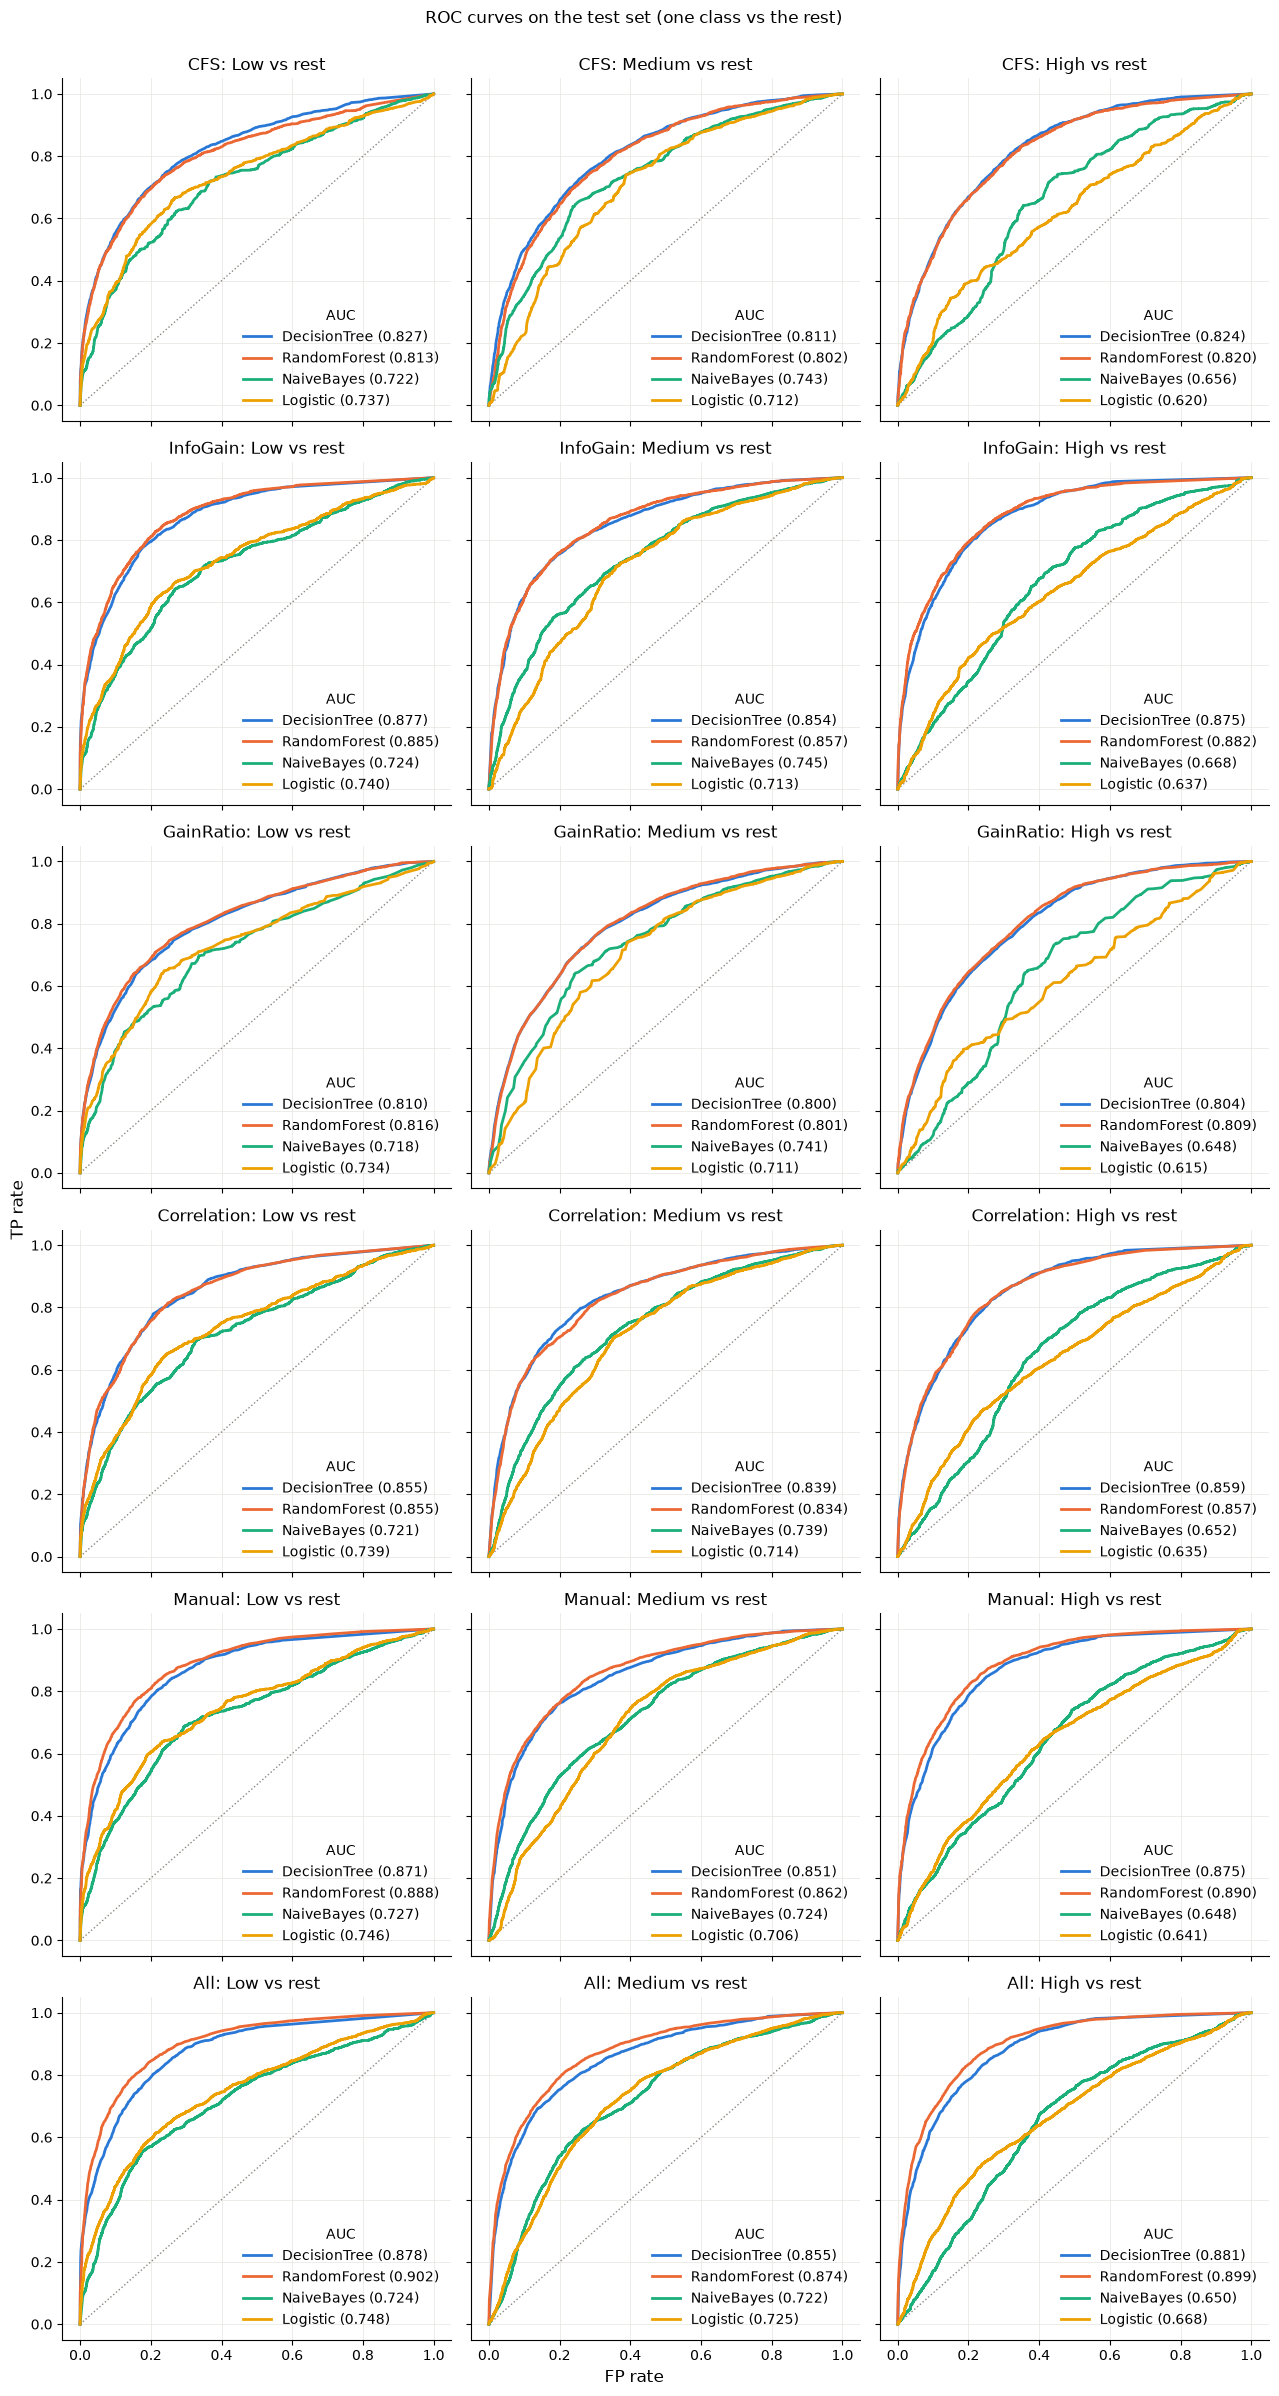

In [12]:
colors = dict(zip(classifiers, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]))

fig, axes = plt.subplots(len(attribute_sets), 3, figsize=(13, 4 * len(attribute_sets)), sharex=True, sharey=True, squeeze=False)
for row, set_name in zip(axes, attribute_sets):
    for i, (ax, class_name) in enumerate(zip(row, CLASSES)):
        ax.plot([0, 1], [0, 1], color="#898781", linestyle=":", linewidth=1)
        for clf_name in classifiers:
            prob = probabilities[set_name, clf_name][:, i]
            fpr, tpr, _ = roc_curve(y_test == i, prob)
            ax.plot(fpr, tpr, color=colors[clf_name], linewidth=2, label=f"{clf_name} ({roc_auc_score(y_test == i, prob):.3f})")
        ax.set_title(f"{set_name}: {class_name} vs rest")
        ax.legend(title="AUC", loc="lower right", frameon=False)
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(color="#e6e5e0", linewidth=0.5)
fig.supxlabel("FP rate")
fig.supylabel("TP rate")
fig.suptitle("ROC curves on the test set (one class vs the rest)", y=1)
plt.tight_layout()
plt.show()

## 4. Best model

In [13]:
best = results.sort_values("AUC", ascending=False).iloc[0]
best

attributes             All
classifier    RandomForest
accuracy             0.743
TP_Low               0.680
TP_Medium            0.787
TP_High              0.724
FP_Low               0.083
FP_Medium            0.202
FP_High              0.123
TP_rate              0.743
FP_rate              0.150
AUC                  0.888
Name: 21, dtype: object

In [14]:
prob = probabilities[best.attributes, best.classifier]
pd.DataFrame(
    confusion_matrix(y_test, prob.argmax(axis=1)),
    index=[f"actual {c}" for c in CLASSES],
    columns=[f"predicted {c}" for c in CLASSES],
)

,predicted Low,predicted Medium,predicted High
actual Low,1373,421,226
actual Medium,338,3157,517
actual High,215,528,1945


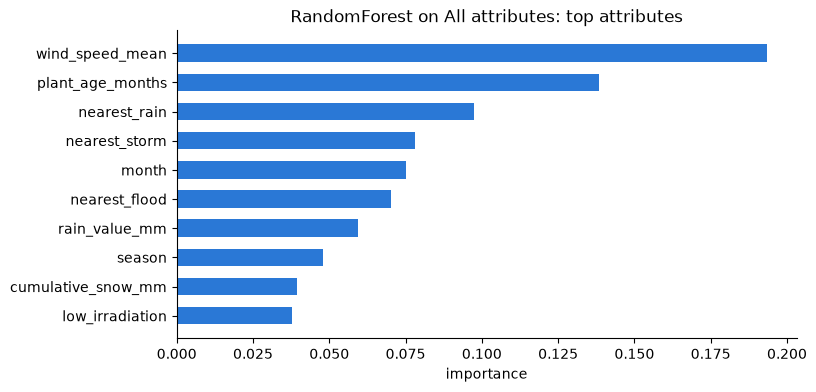

In [15]:
cols = attribute_sets[best.attributes]
model = classifiers[best.classifier].fit(X_train[cols], y_train)
importance = pd.Series(model.feature_importances_, index=cols).nlargest(10).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(importance.index, importance.values, color="#2a78d6", height=0.6)
ax.set(xlabel="importance", title=f"{best.classifier} on {best.attributes} attributes: top attributes")
ax.spines[["top", "right"]].set_visible(False)
plt.show()